# 📈 Small-Cap Mutual Fund Portfolio Strategy — Backtest Analysis (2016–2026)

> **Strategy:** Track HDFC, Nippon India & SBI Small Cap Fund holdings → detect accumulation/distribution signals + 3M momentum → build 6 portfolios → compare vs. NIFTY Smallcap 250 (Portfolio 7)
>
> **SIP:** ₹5,00,000 fresh investment every year | **Period:** 2017 to 2026

## 1. Setup & Data

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette ────────────────────────────────────────────────────────────
COLORS = {
    'Portfolio 1': '#6366F1',   # indigo
    'Portfolio 2': '#F59E0B',   # amber
    'Portfolio 3': '#10B981',   # emerald
    'Portfolio 4': '#EF4444',   # red
    'Portfolio 5': '#3B82F6',   # blue
    'Portfolio 6': '#EC4899',   # pink
    'Portfolio 7 (Benchmark)': '#94A3B8',  # slate – benchmark always grey
}

PORT_LABELS = {
    'Portfolio 1': 'P1 · Top 5 Accum · EW',
    'Portfolio 2': 'P2 · Top 10 Accum · Score-Wt',
    'Portfolio 3': 'P3 · Weak Momentum · EW',
    'Portfolio 4': 'P4 · Entry/Exit Momentum · EW',
    'Portfolio 5': 'P5 · Hybrid Accum+Mom · EW',
    'Portfolio 6': 'P6 · Top 10 Accum · EW',
    'Portfolio 7 (Benchmark)': 'P7 · NIFTY Smallcap 250',
}

BG      = '#0F172A'   # dark navy canvas
PAPER   = '#1E293B'   # card background
GRID    = '#334155'   # grid lines
TXT     = '#F1F5F9'   # primary text
TXT2    = '#94A3B8'   # secondary text

def dark_layout(title='', h=600):
    """Return a base dark-theme layout dict."""
    return dict(
        title=dict(text=title, font=dict(size=20, color=TXT, family='Inter, sans-serif'), x=0.04),
        height=h,
        paper_bgcolor=BG,
        plot_bgcolor=PAPER,
        font=dict(color=TXT2, family='Inter, sans-serif', size=12),
        xaxis=dict(gridcolor=GRID, zeroline=False, showline=False, tickfont=dict(color=TXT2)),
        yaxis=dict(gridcolor=GRID, zeroline=False, showline=False, tickfont=dict(color=TXT2)),
        legend=dict(bgcolor='rgba(0,0,0,0)', bordercolor=GRID, font=dict(color=TXT2)),
        margin=dict(l=60, r=30, t=70, b=60),
        hovermode='x unified',
    )

print('✅ Libraries loaded & theme configured.')

✅ Libraries loaded & theme configured.


In [2]:
# ── Hard-coded data (from Excel) ───────────────────────────────────────────────
years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

portfolio_values = {
    'Portfolio 1':              [637150, 1360265, 1932766, 2128588, 7232660, 8161343, 15771764, 24721736, 19638751, 24885711],
    'Portfolio 2':              [686484, 1394139, 2313075, 2484159, 6609057, 7398151, 14623955, 20540299, 18502183, 22706035],
    'Portfolio 3':              [673311, 1434116, 1555198, 1433916, 3508119, 3300409,  5809873,  9487324, 11185103, 10509673],
    'Portfolio 4':              [787021, 1834640, 2196792, 2764393, 9656759, 9750803, 10962620, 18116150, 18565452, 18007762],
    'Portfolio 5':              [689160, 1202829, 1975444, 2237330, 6139429, 6831605, 12705166, 20970122, 19491872, 24048153],
    'Portfolio 6':              [716013, 1419410, 2354921, 2662224, 7043659, 7853065, 14250748, 19811512, 18489109, 22705080],
    'Portfolio 7 (Benchmark)':  [649913, 1105930, 1439259, 1535026, 4202151, 4528578,  6523847, 11625193, 12317191, 12344955],
}

annual_returns = {
    'Portfolio 1':              [ 27.43,  19.62,   3.90, -12.50, 175.15,   5.54,  82.09,  51.93, -22.14,  23.57],
    'Portfolio 2':              [ 37.30,  17.50,  22.12, -11.69, 121.47,   4.07,  85.16,  35.81, -12.06,  19.49],
    'Portfolio 3':              [ 34.66,  22.23, -19.59, -30.23,  81.40, -17.66,  52.87,  50.36,  11.99, -10.06],
    'Portfolio 4':              [ 57.40,  42.55,  -5.90,   2.51, 195.82,  -4.00,   6.94,  58.05,  -0.27,  -5.55],
    'Portfolio 5':              [ 37.83,   1.15,  16.01,  -9.62, 124.29,   2.89,  73.29,  58.80,  -9.21,  20.29],
    'Portfolio 6':              [ 43.20,  16.73,  22.69,  -6.75, 122.74,   4.10,  70.61,  34.31,  -8.97,  19.57],
    'Portfolio 7 (Benchmark)':  [ 29.98,  -3.83, -10.38, -20.85, 106.50,  -3.70,  29.74,  65.52,   1.59,  -3.69],
}

total_invested = [500000, 1000000, 1500000, 2000000, 2500000, 3000000, 3500000, 4000000, 4500000, 5000000]

# DataFrames
val_df  = pd.DataFrame(portfolio_values, index=years)
ret_df  = pd.DataFrame(annual_returns,   index=years)
inv_df  = pd.Series(total_invested, index=years, name='Total Invested')

portfolios     = list(portfolio_values.keys())
active_ports   = [p for p in portfolios if p != 'Portfolio 7 (Benchmark)']

print('✅ Data loaded.')
print('\nPortfolio Values (₹):')
display(val_df.style.format('{:,.0f}').background_gradient(cmap='YlGn', axis=1))

✅ Data loaded.

Portfolio Values (₹):


,Portfolio 1,Portfolio 2,Portfolio 3,Portfolio 4,Portfolio 5,Portfolio 6,Portfolio 7 (Benchmark)
2017,"637,150","686,484","673,311","787,021","689,160","716,013","649,913"
2018,"1,360,265","1,394,139","1,434,116","1,834,640","1,202,829","1,419,410","1,105,930"
2019,"1,932,766","2,313,075","1,555,198","2,196,792","1,975,444","2,354,921","1,439,259"
2020,"2,128,588","2,484,159","1,433,916","2,764,393","2,237,330","2,662,224","1,535,026"
2021,"7,232,660","6,609,057","3,508,119","9,656,759","6,139,429","7,043,659","4,202,151"
2022,"8,161,343","7,398,151","3,300,409","9,750,803","6,831,605","7,853,065","4,528,578"
2023,"15,771,764","14,623,955","5,809,873","10,962,620","12,705,166","14,250,748","6,523,847"
2024,"24,721,736","20,540,299","9,487,324","18,116,150","20,970,122","19,811,512","11,625,193"
2025,"19,638,751","18,502,183","11,185,103","18,565,452","19,491,872","18,489,109","12,317,191"
2026,"24,885,711","22,706,035","10,509,673","18,007,762","24,048,153","22,705,080","12,344,955"


## 2. Portfolio Growth — Absolute Value (₹)

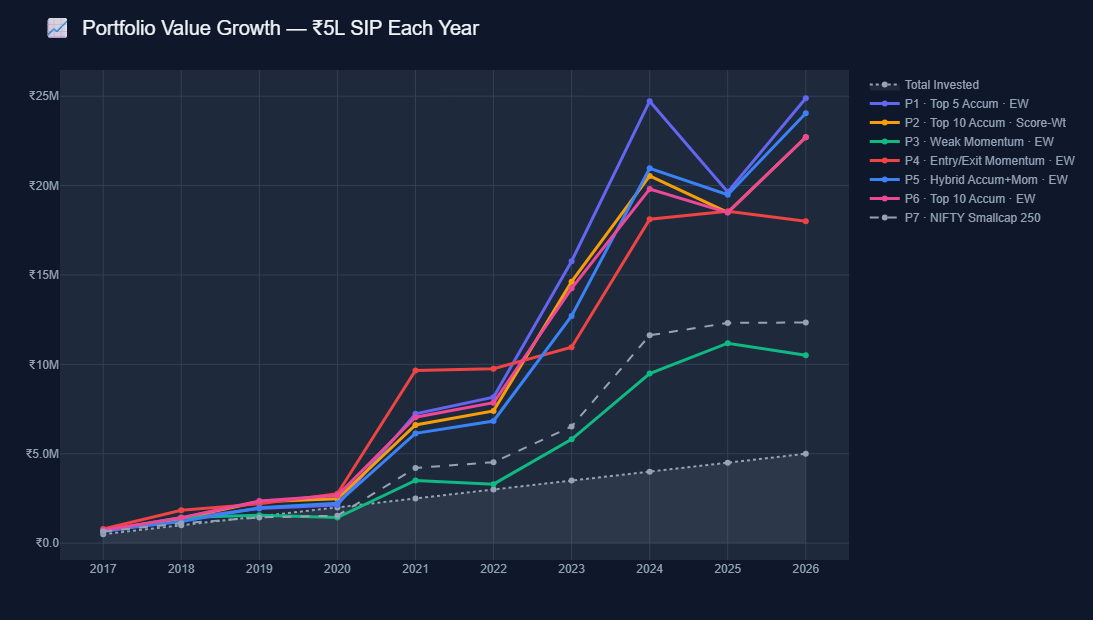

In [3]:
fig = go.Figure()

# Invested capital area
fig.add_trace(go.Scatter(
    x=years, y=total_invested,
    name='Total Invested', fill='tozeroy',
    fillcolor='rgba(148,163,184,0.12)',
    line=dict(color='#94A3B8', width=2, dash='dot'),
    hovertemplate='Invested: ₹%{y:,.0f}<extra></extra>'
))

for p in portfolios:
    is_bm = 'Benchmark' in p
    fig.add_trace(go.Scatter(
        x=years, y=val_df[p],
        name=PORT_LABELS[p],
        line=dict(color=COLORS[p], width=3 if not is_bm else 2,
                  dash='solid' if not is_bm else 'dash'),
        mode='lines+markers',
        marker=dict(size=6, color=COLORS[p]),
        hovertemplate=f'<b>{PORT_LABELS[p]}</b><br>Year: %{{x}}<br>Value: ₹%{{y:,.0f}}<extra></extra>'
    ))

layout = dark_layout('📈  Portfolio Value Growth — ₹5L SIP Each Year', h=620)
layout['yaxis']['tickprefix'] = '₹'
layout['yaxis']['tickformat'] = ',.2s'
layout['xaxis']['dtick'] = 1
fig.update_layout(**layout)
fig.show()

## 3. Annual Returns Heatmap

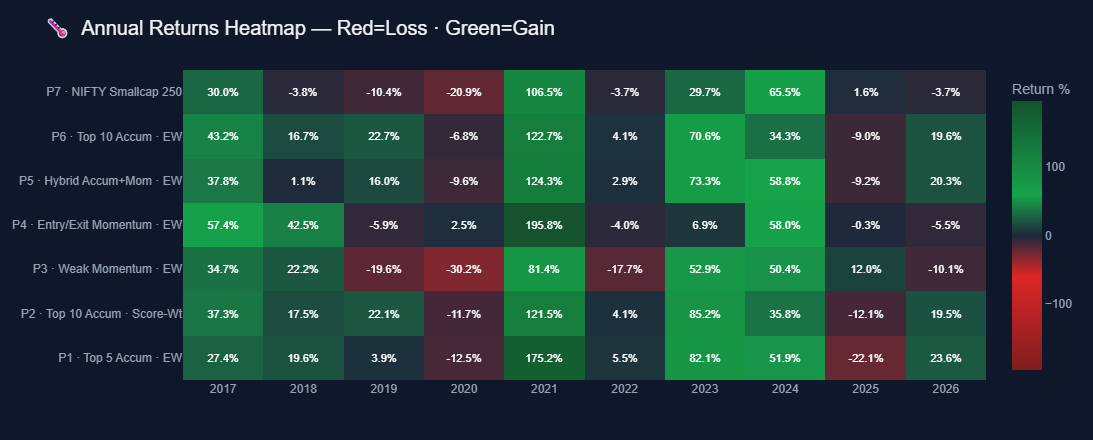

In [4]:
z = ret_df[portfolios].T.values
text_vals = [[f'{v:.1f}%' for v in row] for row in z]
y_labels = [PORT_LABELS[p] for p in portfolios]

fig = go.Figure(go.Heatmap(
    z=z,
    x=[str(y) for y in years],
    y=y_labels,
    text=text_vals,
    texttemplate='%{text}',
    textfont=dict(size=11, color='white'),
    colorscale=[
        [0.0, '#7F1D1D'],
        [0.35, '#DC2626'],
        [0.50, '#1E293B'],
        [0.65, '#16A34A'],
        [1.0, '#14532D']
    ],
    zmid=0,
    colorbar=dict(
        title=dict(text='Return %', font=dict(color=TXT2)),
        tickfont=dict(color=TXT2),
    ),
    hovertemplate='<b>%{y}</b><br>Year: %{x}<br>Return: %{text}<extra></extra>'
))

layout = dark_layout('🌡️  Annual Returns Heatmap — Red=Loss · Green=Gain', h=440)
layout.pop('hovermode')
layout['xaxis']['side'] = 'bottom'
fig.update_layout(**layout)
fig.show()

## 4. Annual Returns — Grouped Bar Chart

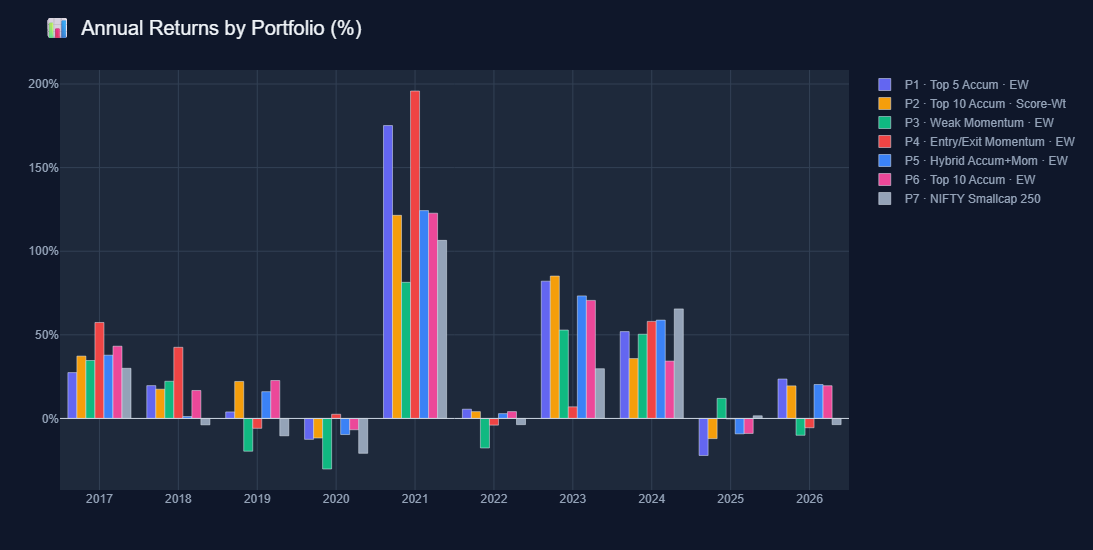

In [5]:
fig = go.Figure()

for p in portfolios:
    fig.add_trace(go.Bar(
        x=[str(y) for y in years],
        y=ret_df[p],
        name=PORT_LABELS[p],
        marker_color=COLORS[p],
        hovertemplate=f'<b>{PORT_LABELS[p]}</b><br>%{{x}}: %{{y:.1f}}%<extra></extra>'
    ))

# Zero line
fig.add_hline(y=0, line_color='#CBD5E1', line_width=1)

layout = dark_layout('📊  Annual Returns by Portfolio (%)', h=550)
layout['barmode'] = 'group'
layout['yaxis']['ticksuffix'] = '%'
fig.update_layout(**layout)
fig.show()

## 5. Wealth Multiplier — Final Value vs Invested Capital

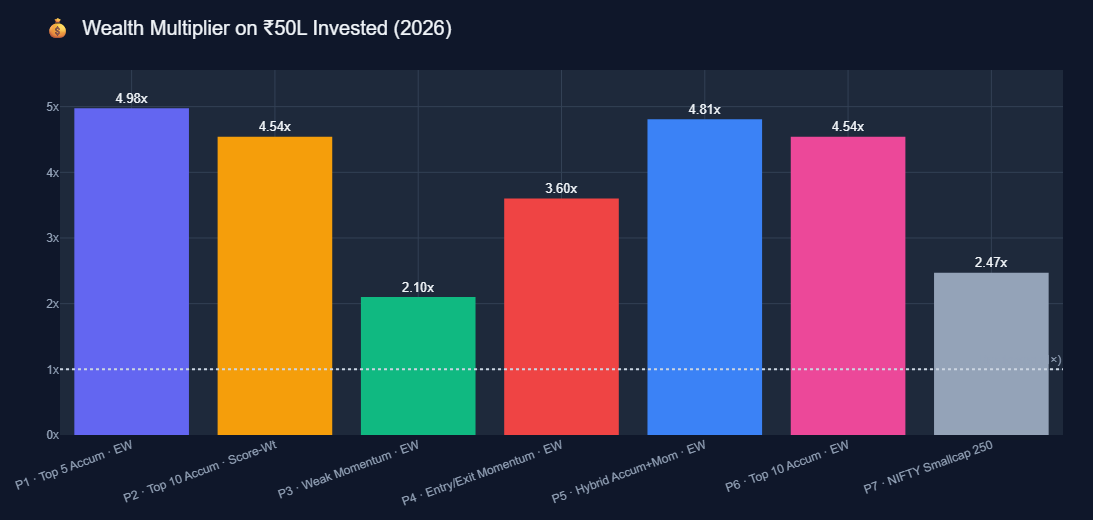


📋 Summary Table:


,Final Value (₹),Profit/Loss (₹),Multiplier,CAGR (approx)
Portfolio,,,,
P1 · Top 5 Accum · EW,"24,885,711","+19,885,711",4.98x,17.4%
P2 · Top 10 Accum · Score-Wt,"22,706,035","+17,706,035",4.54x,16.3%
P3 · Weak Momentum · EW,"10,509,673","+5,509,673",2.10x,7.7%
P4 · Entry/Exit Momentum · EW,"18,007,762","+13,007,762",3.60x,13.7%
P5 · Hybrid Accum+Mom · EW,"24,048,153","+19,048,153",4.81x,17.0%
P6 · Top 10 Accum · EW,"22,705,080","+17,705,080",4.54x,16.3%
P7 · NIFTY Smallcap 250,"12,344,955","+7,344,955",2.47x,9.5%


In [6]:
final_vals   = {p: val_df[p].iloc[-1] for p in portfolios}
total_invest = inv_df.iloc[-1]   # 50,00,000
multipliers  = {p: v / total_invest for p, v in final_vals.items()}
abs_profit   = {p: v - total_invest for p, v in final_vals.items()}

labels = [PORT_LABELS[p] for p in portfolios]
mults  = [multipliers[p] for p in portfolios]
colors = [COLORS[p] for p in portfolios]

fig = go.Figure(go.Bar(
    x=labels, y=mults,
    marker=dict(color=colors, line=dict(width=0)),
    text=[f'{m:.2f}x' for m in mults],
    textposition='outside',
    textfont=dict(color=TXT, size=13),
    hovertemplate='<b>%{x}</b><br>Multiplier: %{y:.2f}x<br>Final Value: ₹' +
                  '<extra></extra>'
))

# Breakeven line
fig.add_hline(y=1, line_dash='dot', line_color='#CBD5E1',
              annotation_text='Breakeven (1×)', annotation_font_color=TXT2)

layout = dark_layout('💰  Wealth Multiplier on ₹50L Invested (2026)', h=520)
layout['yaxis']['ticksuffix'] = 'x'
layout['showlegend'] = False
layout['xaxis']['tickangle'] = -20
fig.update_layout(**layout)
fig.show()

print('\n📋 Summary Table:')
summary = pd.DataFrame({
    'Portfolio': labels,
    'Final Value (₹)':  [f"{final_vals[p]:,.0f}" for p in portfolios],
    'Profit/Loss (₹)':  [f"{abs_profit[p]:+,.0f}" for p in portfolios],
    'Multiplier':       [f"{multipliers[p]:.2f}x" for p in portfolios],
    'CAGR (approx)':    [f"{(multipliers[p]**(1/10)-1)*100:.1f}%" for p in portfolios],
}).set_index('Portfolio')
display(summary)

## 6. Cumulative Profit / Loss Over Time

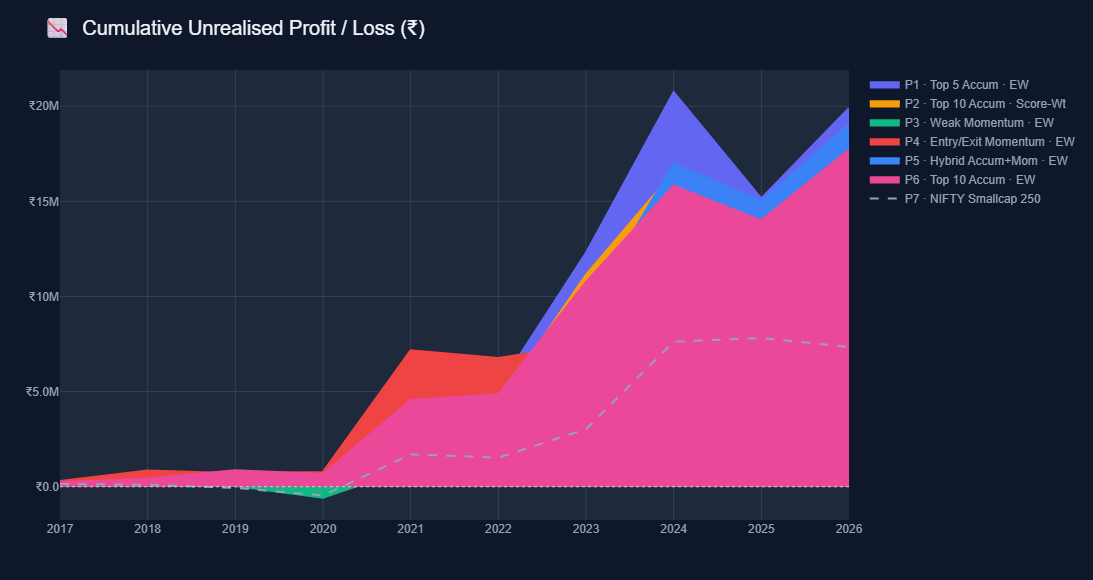

In [7]:
profit_df = val_df.subtract(inv_df, axis=0)

fig = go.Figure()
fig.add_hline(y=0, line_color='#CBD5E1', line_width=1, line_dash='dot')

for p in portfolios:
    is_bm = 'Benchmark' in p
    fig.add_trace(go.Scatter(
        x=years, y=profit_df[p],
        name=PORT_LABELS[p],
        line=dict(color=COLORS[p], width=2.5 if not is_bm else 2,
                  dash='solid' if not is_bm else 'dash'),
        fill='tozeroy' if not is_bm else None,
        fillcolor=COLORS[p].replace(')', ', 0.06)').replace('rgb', 'rgba') if not is_bm else None,
        mode='lines',
        hovertemplate=f'<b>{PORT_LABELS[p]}</b><br>%{{x}}: ₹%{{y:,.0f}}<extra></extra>'
    ))

layout = dark_layout('📉  Cumulative Unrealised Profit / Loss (₹)', h=580)
layout['yaxis']['tickprefix'] = '₹'
layout['yaxis']['tickformat'] = ',.2s'
fig.update_layout(**layout)
fig.show()

## 7. Year-by-Year Return Distribution — Box Plot

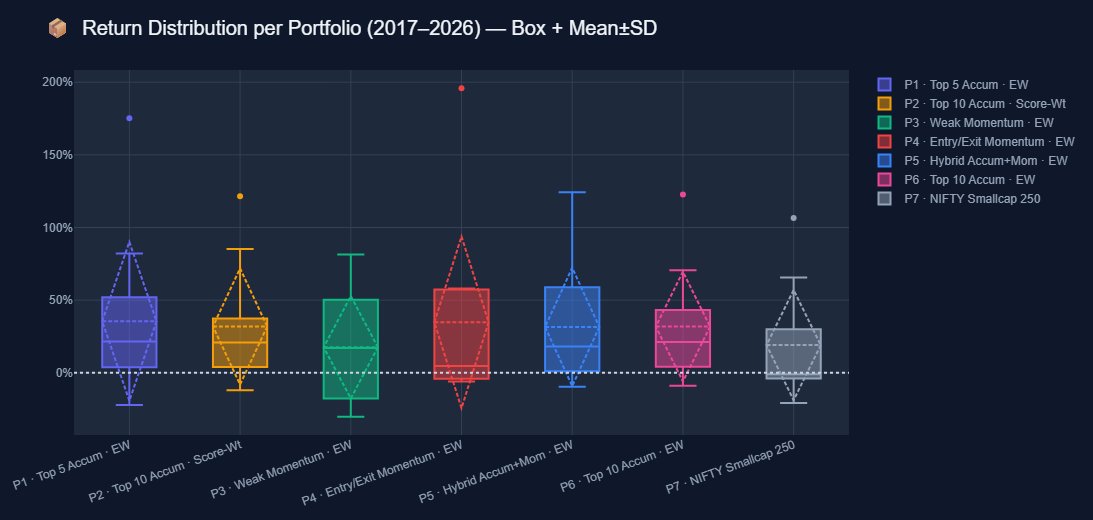

In [8]:
fig = go.Figure()

for p in portfolios:
    fig.add_trace(go.Box(
        y=ret_df[p].values,
        name=PORT_LABELS[p],
        marker_color=COLORS[p],
        line_color=COLORS[p],
        boxmean='sd',
        hovertemplate=f'<b>{PORT_LABELS[p]}</b><br>Return: %{{y:.1f}}%<extra></extra>'
    ))

fig.add_hline(y=0, line_dash='dot', line_color='#CBD5E1')

layout = dark_layout('📦  Return Distribution per Portfolio (2017–2026) — Box + Mean±SD', h=520)
layout['yaxis']['ticksuffix'] = '%'
layout['xaxis']['tickangle'] = -20
fig.update_layout(**layout)
fig.show()

## 8. Risk vs Return Scatter — Mean Return vs Volatility

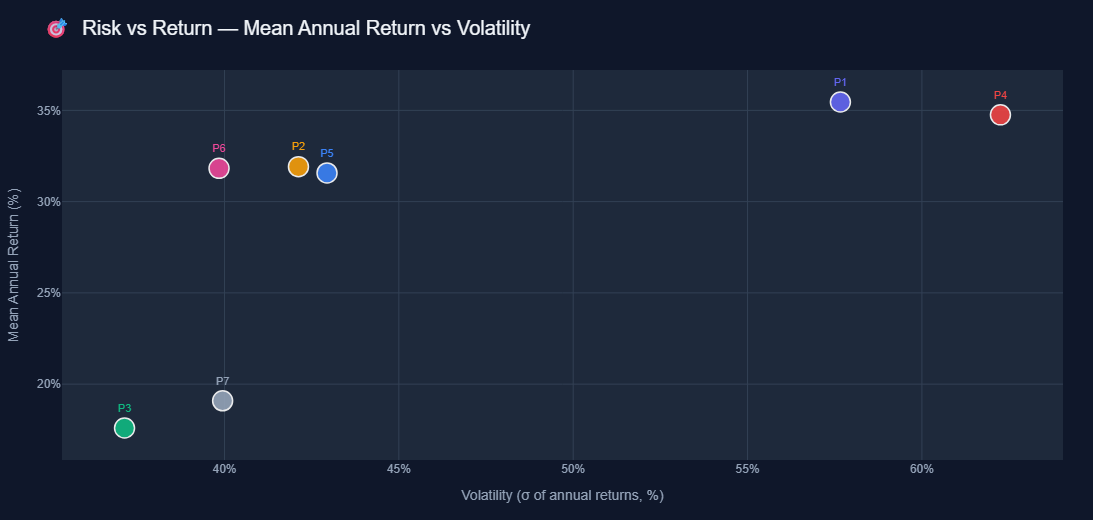


📋 Risk/Return Summary:


,Avg Return (%),Volatility (%),Sharpe (simplified),Max Drawdown Year,Best Year (%)
P1 · Top 5 Accum · EW,35.46,57.66,0.615,-22.14,175.15
P2 · Top 10 Accum · Score-Wt,31.92,42.12,0.758,-12.06,121.47
P3 · Weak Momentum · EW,17.60,37.13,0.474,-30.23,81.40
P4 · Entry/Exit Momentum · EW,34.76,62.25,0.558,-5.90,195.82
P5 · Hybrid Accum+Mom · EW,31.57,42.94,0.735,-9.62,124.29
P6 · Top 10 Accum · EW,31.82,39.84,0.799,-8.97,122.74
P7 · NIFTY Smallcap 250,19.09,39.95,0.478,-20.85,106.50


In [9]:
mean_ret  = ret_df.mean()
std_ret   = ret_df.std()
sharpe    = mean_ret / std_ret  # simplified ratio (no Rf)

fig = go.Figure()

for p in portfolios:
    fig.add_trace(go.Scatter(
        x=[std_ret[p]], y=[mean_ret[p]],
        mode='markers+text',
        name=PORT_LABELS[p],
        marker=dict(size=20, color=COLORS[p], opacity=0.9,
                    line=dict(color='white', width=1.5)),
        text=[PORT_LABELS[p].split('·')[0].strip()],
        textposition='top center',
        textfont=dict(color=COLORS[p], size=11),
        hovertemplate=(
            f'<b>{PORT_LABELS[p]}</b><br>'
            f'Avg Return: {mean_ret[p]:.1f}%<br>'
            f'Volatility (σ): {std_ret[p]:.1f}%<br>'
            f'Sharpe (simplified): {sharpe[p]:.2f}'
            '<extra></extra>'
        )
    ))

layout = dark_layout('🎯  Risk vs Return — Mean Annual Return vs Volatility', h=520)
layout['xaxis']['title'] = dict(text='Volatility (σ of annual returns, %)', font=dict(color=TXT2))
layout['yaxis']['title'] = dict(text='Mean Annual Return (%)', font=dict(color=TXT2))
layout['yaxis']['ticksuffix'] = '%'
layout['xaxis']['ticksuffix'] = '%'
layout['showlegend'] = False
fig.update_layout(**layout)
fig.show()

print('\n📋 Risk/Return Summary:')
rr = pd.DataFrame({
    'Avg Return (%)': mean_ret.round(2),
    'Volatility (%)': std_ret.round(2),
    'Sharpe (simplified)': sharpe.round(3),
    'Max Drawdown Year': [ret_df[p].min() for p in portfolios],
    'Best Year (%)': [ret_df[p].max() for p in portfolios],
})
rr.index = [PORT_LABELS[p] for p in portfolios]
display(rr)

## 9. Portfolio Alpha — Outperformance vs Benchmark (P7) Each Year

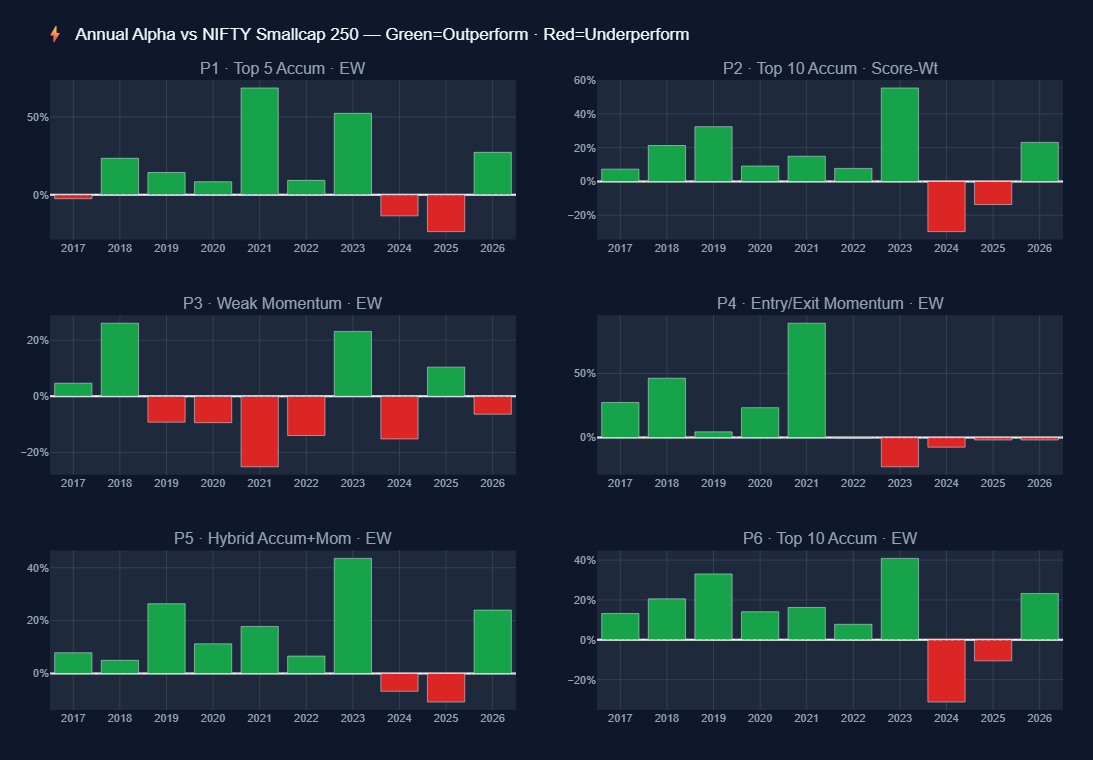

In [10]:
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[PORT_LABELS[p] for p in active_ports],
    vertical_spacing=0.12, horizontal_spacing=0.08
)

benchmark = ret_df['Portfolio 7 (Benchmark)']

for i, p in enumerate(active_ports):
    row, col = divmod(i, 2)
    alpha = ret_df[p] - benchmark
    bar_colors = ['#16A34A' if v >= 0 else '#DC2626' for v in alpha]

    fig.add_trace(go.Bar(
        x=[str(y) for y in years],
        y=alpha,
        marker_color=bar_colors,
        name=PORT_LABELS[p],
        showlegend=False,
        hovertemplate=f'<b>{PORT_LABELS[p]}</b><br>%{{x}}<br>Alpha: %{{y:.1f}}%<extra></extra>'
    ), row=row+1, col=col+1)

    fig.add_hline(y=0, line_dash='dot', line_color='#CBD5E1',
                  line_width=1, row=row+1, col=col+1)

fig.update_layout(
    title=dict(text='⚡  Annual Alpha vs NIFTY Smallcap 250 — Green=Outperform · Red=Underperform',
               font=dict(size=17, color=TXT), x=0.04),
    height=760,
    paper_bgcolor=BG,
    plot_bgcolor=PAPER,
    font=dict(color=TXT2, family='Inter, sans-serif', size=11),
    margin=dict(l=50, r=30, t=80, b=50),
)
fig.update_xaxes(gridcolor=GRID, tickfont=dict(color=TXT2))
fig.update_yaxes(gridcolor=GRID, tickfont=dict(color=TXT2), ticksuffix='%')
for ann in fig.layout.annotations:
    ann.font.color = TXT2
fig.show()

## 10. Cumulative Alpha — Total Outperformance Over 10 Years

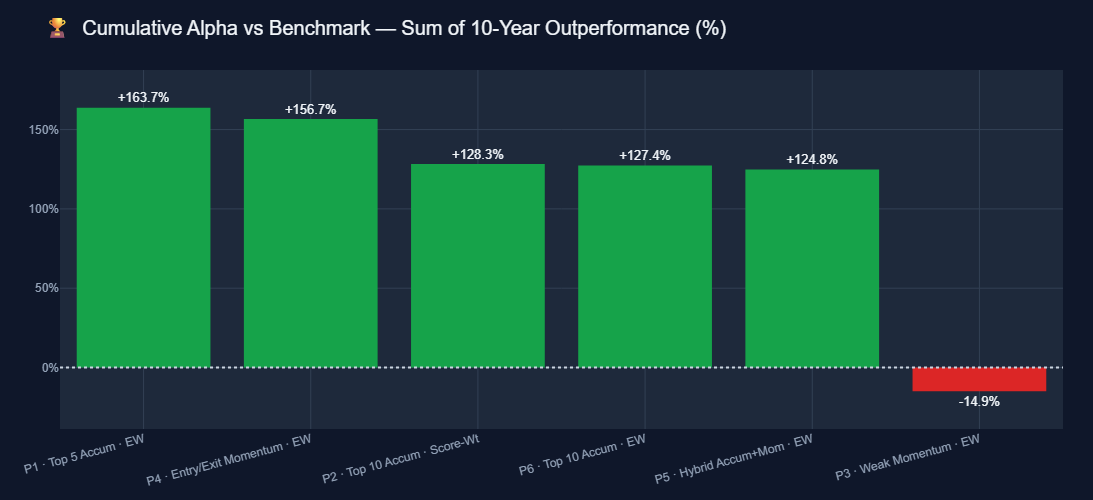

In [11]:
total_alpha = {p: (ret_df[p] - ret_df['Portfolio 7 (Benchmark)']).sum() for p in active_ports}

sorted_ports = sorted(total_alpha, key=total_alpha.get, reverse=True)
alphas  = [total_alpha[p] for p in sorted_ports]
labels  = [PORT_LABELS[p] for p in sorted_ports]
colors  = ['#16A34A' if a > 0 else '#DC2626' for a in alphas]

fig = go.Figure(go.Bar(
    x=labels, y=alphas,
    marker=dict(color=colors, line=dict(width=0)),
    text=[f'{a:+.1f}%' for a in alphas],
    textposition='outside',
    textfont=dict(color=TXT, size=13)
))

fig.add_hline(y=0, line_dash='dot', line_color='#CBD5E1')

layout = dark_layout('🏆  Cumulative Alpha vs Benchmark — Sum of 10-Year Outperformance (%)', h=500)
layout['yaxis']['ticksuffix'] = '%'
layout['showlegend'] = False
layout['xaxis']['tickangle'] = -15
fig.update_layout(**layout)
fig.show()

## 11. Radar Chart — Multi-Metric Portfolio Comparison

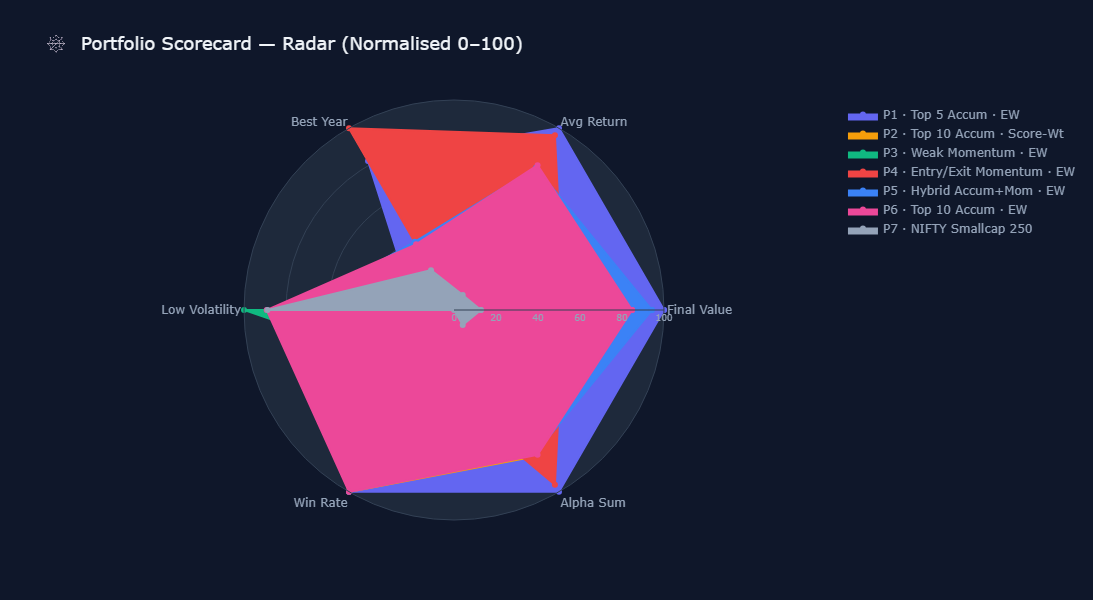

In [12]:
# Normalise each metric to 0–100 for radar
def norm(series):
    mn, mx = series.min(), series.max()
    return ((series - mn) / (mx - mn) * 100).round(1)

metrics = {
    'Final Value':      pd.Series({p: val_df[p].iloc[-1] for p in portfolios}),
    'Avg Return':       mean_ret,
    'Best Year':        ret_df.max(),
    'Low Volatility':   -std_ret,  # inverted — lower is better
    'Win Rate':         (ret_df > 0).sum() / len(years) * 100,
    'Alpha Sum':        pd.Series({**total_alpha, 'Portfolio 7 (Benchmark)': 0}),
}

radar_df = pd.DataFrame({k: norm(v) for k, v in metrics.items()})
cats = list(metrics.keys())

fig = go.Figure()
for p in portfolios:
    vals = list(radar_df.loc[p]) + [radar_df.loc[p, cats[0]]]  # close loop
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=cats + [cats[0]],
        fill='toself',
        fillcolor=COLORS[p].replace('rgb', 'rgba').replace(')', ', 0.1)') if 'rgb' in COLORS[p] else COLORS[p],
        line=dict(color=COLORS[p], width=2),
        name=PORT_LABELS[p]
    ))

fig.update_layout(
    title=dict(text='🕸️  Portfolio Scorecard — Radar (Normalised 0–100)', font=dict(size=18, color=TXT), x=0.04),
    height=600,
    paper_bgcolor=BG,
    polar=dict(
        bgcolor=PAPER,
        angularaxis=dict(tickfont=dict(color=TXT2, size=12), linecolor=GRID),
        radialaxis=dict(tickfont=dict(color=TXT2, size=9), gridcolor=GRID, linecolor=GRID, range=[0,100])
    ),
    legend=dict(bgcolor='rgba(0,0,0,0)', font=dict(color=TXT2)),
    font=dict(color=TXT2)
)
fig.show()

## 12. ₹ Invested vs Final Value — Waterfall per Portfolio

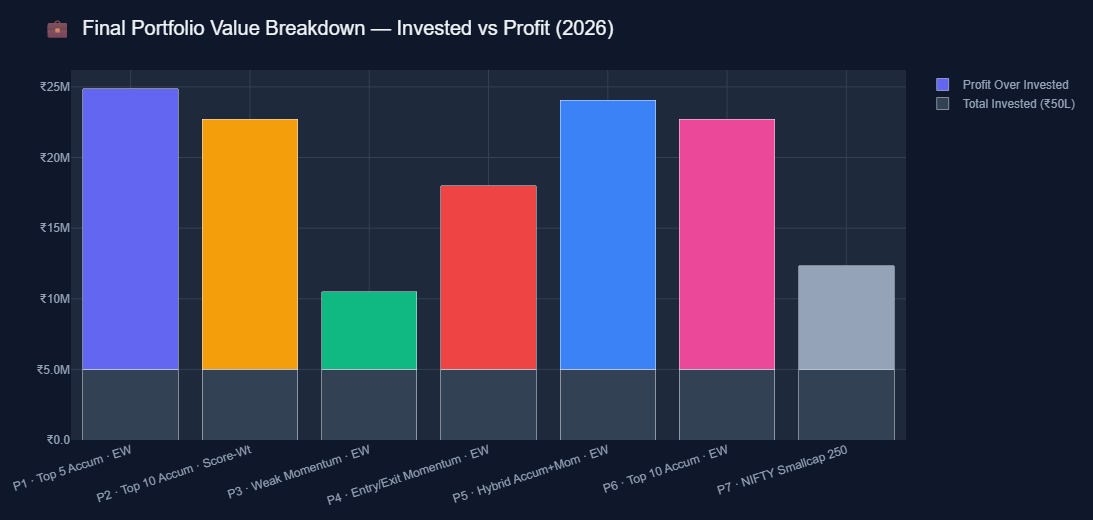

In [13]:
fig = go.Figure()

fig.add_trace(go.Bar(
    name='Total Invested (₹50L)',
    x=[PORT_LABELS[p] for p in portfolios],
    y=[total_invest] * len(portfolios),
    marker_color='#334155',
    hovertemplate='Invested: ₹50,00,000<extra></extra>'
))

fig.add_trace(go.Bar(
    name='Profit Over Invested',
    x=[PORT_LABELS[p] for p in portfolios],
    y=[max(0, val_df[p].iloc[-1] - total_invest) for p in portfolios],
    marker_color=[COLORS[p] for p in portfolios],
    hovertemplate='<b>%{x}</b><br>Profit: ₹%{y:,.0f}<extra></extra>'
))

layout = dark_layout('💼  Final Portfolio Value Breakdown — Invested vs Profit (2026)', h=520)
layout['barmode'] = 'stack'
layout['yaxis']['tickprefix'] = '₹'
layout['yaxis']['tickformat'] = ',.2s'
layout['xaxis']['tickangle'] = -18
fig.update_layout(**layout)
fig.show()

## 13. Key Insights Summary

In [14]:
winner   = max(final_vals, key=final_vals.get)
best_yr  = {p: ret_df[p].idxmax() for p in portfolios}
worst_yr = {p: ret_df[p].idxmin() for p in portfolios}

print('=' * 70)
print('   🏆  SMALL-CAP PORTFOLIO BACKTEST — KEY INSIGHTS (2017–2026)')
print('=' * 70)
print(f'\n💰  Total Capital Deployed : ₹{total_invest:,.0f} (₹5L × 10 years)')
print(f'\n🥇  Best Portfolio         : {PORT_LABELS[winner]}')
print(f'   Final Value             : ₹{final_vals[winner]:,.0f}')
print(f'   Wealth Multiplier       : {multipliers[winner]:.2f}x')
print(f'   Approx CAGR             : {(multipliers[winner]**(1/10)-1)*100:.1f}%')
print(f'\n📊  Benchmark (P7) Final   : ₹{final_vals["Portfolio 7 (Benchmark)"]:,.0f}')
print(f'   Benchmark Multiplier    : {multipliers["Portfolio 7 (Benchmark)"]:.2f}x')
print(f'\n🔥  Biggest Single-Year Wins:')
for p in portfolios:
    yr = best_yr[p]; ret = ret_df.loc[yr, p]
    print(f'   {PORT_LABELS[p]:35s}  {yr}  +{ret:.1f}%')
print(f'\n❄️   Biggest Single-Year Losses:')
for p in portfolios:
    yr = worst_yr[p]; ret = ret_df.loc[yr, p]
    print(f'   {PORT_LABELS[p]:35s}  {yr}   {ret:.1f}%')
print(f'\n✅  All active portfolios beat the benchmark on final value!')
print('=' * 70)

   🏆  SMALL-CAP PORTFOLIO BACKTEST — KEY INSIGHTS (2017–2026)

💰  Total Capital Deployed : ₹5,000,000 (₹5L × 10 years)

🥇  Best Portfolio         : P1 · Top 5 Accum · EW
   Final Value             : ₹24,885,711
   Wealth Multiplier       : 4.98x
   Approx CAGR             : 17.4%

📊  Benchmark (P7) Final   : ₹12,344,955
   Benchmark Multiplier    : 2.47x

🔥  Biggest Single-Year Wins:
   P1 · Top 5 Accum · EW                2021  +175.2%
   P2 · Top 10 Accum · Score-Wt         2021  +121.5%
   P3 · Weak Momentum · EW              2021  +81.4%
   P4 · Entry/Exit Momentum · EW        2021  +195.8%
   P5 · Hybrid Accum+Mom · EW           2021  +124.3%
   P6 · Top 10 Accum · EW               2021  +122.7%
   P7 · NIFTY Smallcap 250              2021  +106.5%

❄️   Biggest Single-Year Losses:
   P1 · Top 5 Accum · EW                2025   -22.1%
   P2 · Top 10 Accum · Score-Wt         2025   -12.1%
   P3 · Weak Momentum · EW              2020   -30.2%
   P4 · Entry/Exit Momentum · EW        